<a href="https://colab.research.google.com/github/chtmnPlfy/Coffee-in-Trend/blob/main/Importer_and_Exporter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# --- 0. Mount Google Drive (Google Colab environment) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")

BASE_DIR = "/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend"


def locate_file(filename, base_dir=BASE_DIR):
    exact = os.path.join(base_dir, filename)
    if os.path.exists(exact):
        print(f"File found: {exact}")
        return exact
    print(f"File not found at exact path: {exact}")
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        print(f"Found instead at: {matches[0]}")
        return matches[0]
    print(f"Falling back to relative path: {filename}")
    return filename


exports_path = locate_file("green_coffee_bean_exports_2024.csv")
imports_path = locate_file("green_coffee_bean_imports_2024.csv")

exports = pd.read_csv(exports_path)
imports = pd.read_csv(imports_path)

exp_col = "Bean Exports (1000 60 KG BAGS)"
imp_col = "Bean Imports (1000 60 KG BAGS)"


exports["Billion kg"] = exports[exp_col] * 60_000 / 1e9
imports["Billion kg"] = imports[imp_col] * 60_000 / 1e9

top5_exp = exports.nlargest(5, "Billion kg").sort_values("Billion kg", ascending=False)
top5_imp = imports.nlargest(5, "Billion kg").sort_values("Billion kg", ascending=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/green_coffee_bean_exports_2024.csv
File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/green_coffee_bean_imports_2024.csv


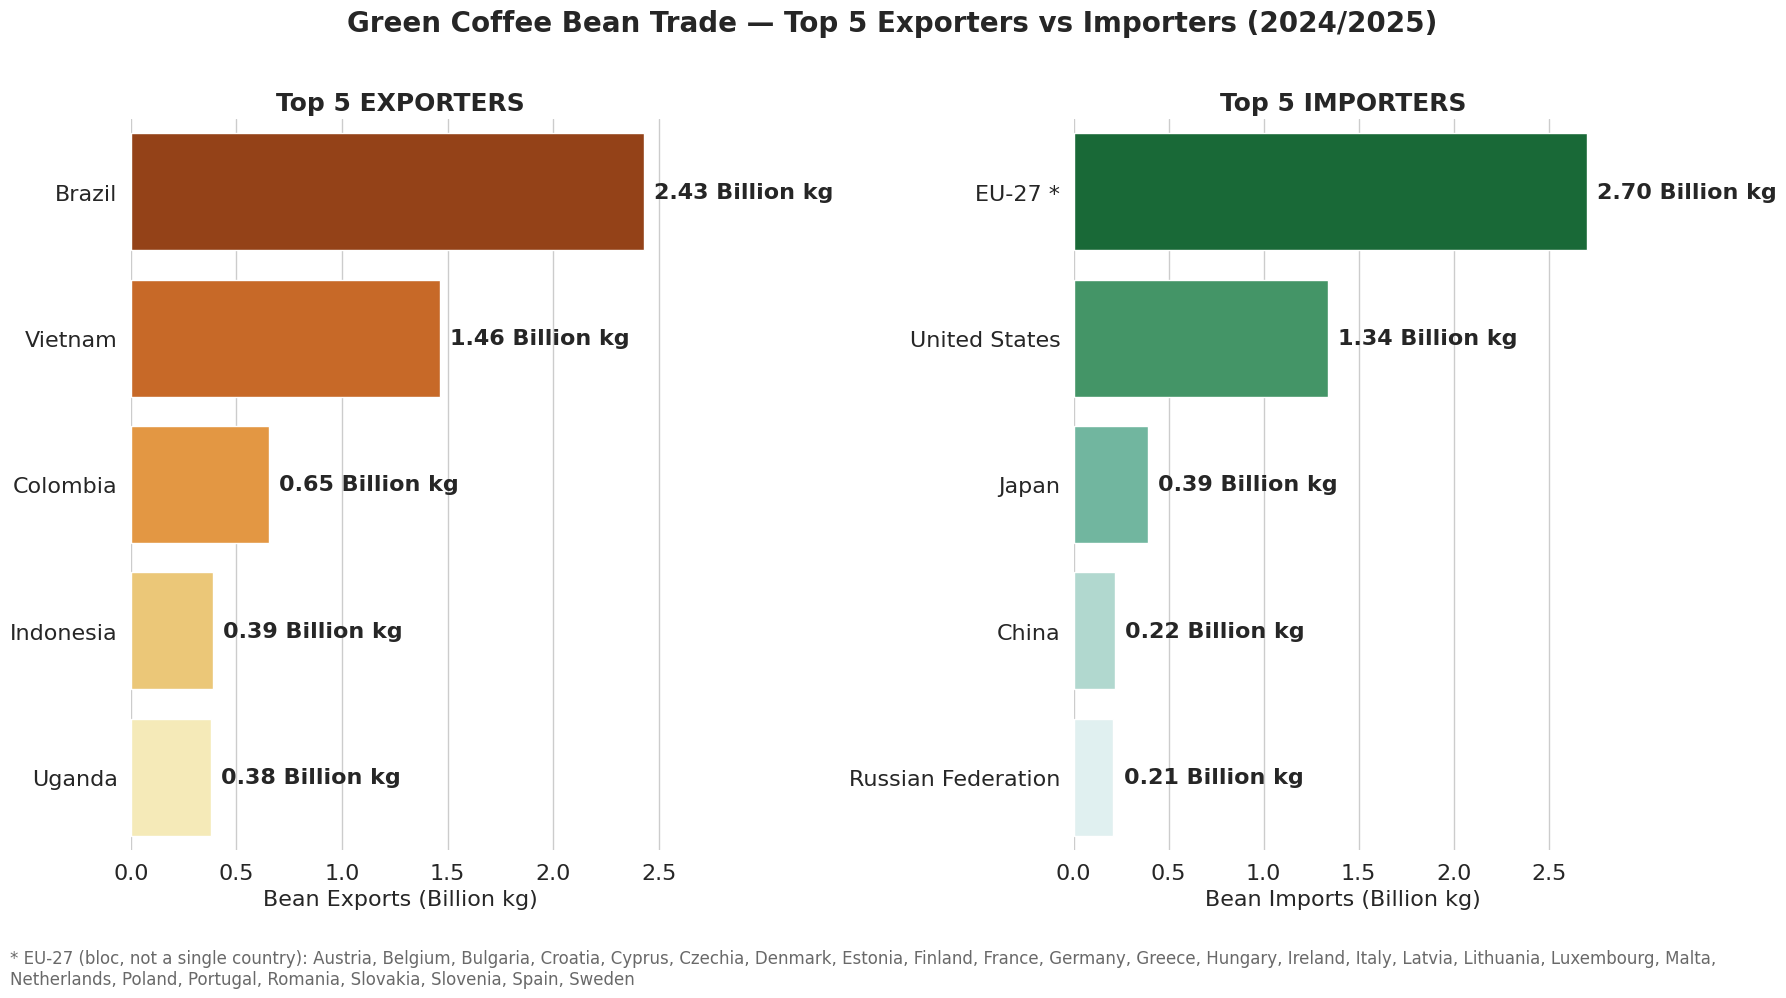


--- Top 5 Exporters ---
  Country  Billion kg
   Brazil       2.430
 Viet Nam       1.464
 Colombia       0.654
Indonesia       0.390
   Uganda       0.378

--- Top 5 Importers ---
           Country  Billion kg
             EU-27       2.700
     United States       1.338
             Japan       0.390
             China       0.216
Russian Federation       0.210


In [4]:
# Mark EU-27 since it's a bloc of 27 countries, not a single country
for d in (top5_exp, top5_imp):
    d["Label"] = d["Country"].replace("Viet Nam", "Vietnam").apply(lambda c: f"{c} *" if c == "EU-27" else c)

EU27_MEMBERS = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden",
]
FOOTNOTE = "* EU-27 (bloc, not a single country): " + ", ".join(EU27_MEMBERS)

#Plot: exporters (left) and importers (right) ---
sns.set_theme(style="whitegrid")
n_bars = 5
figsize = (18, 1.1 * n_bars + 3.5)
fig, axes = plt.subplots(1, 2, figsize=figsize)

TITLE_FS = 20
SUBTITLE_FS = 18
LABEL_FS = 16
FOOTNOTE_FS = 12

# --- Exporters ---
ax = axes[0]
palette_exp = sns.color_palette("YlOrBr", n_colors=5)[::-1]
sns.barplot(data=top5_exp, x="Billion kg", y="Label", hue="Label",
            palette=palette_exp, legend=False, ax=ax)
for i, v in enumerate(top5_exp["Billion kg"]):
    ax.text(v + top5_exp["Billion kg"].max() * 0.02, i, f"{v:,.2f} Billion kg",
            va="center", fontsize=LABEL_FS, fontweight="bold")
ax.set_title("Top 5 EXPORTERS", fontsize=SUBTITLE_FS, fontweight="bold")
ax.set_xlabel("Bean Exports (Billion kg)", fontsize=LABEL_FS)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=LABEL_FS)

# --- Importers ---
ax = axes[1]
palette_imp = sns.color_palette("BuGn", n_colors=5)[::-1]
sns.barplot(data=top5_imp, x="Billion kg", y="Label", hue="Label",
            palette=palette_imp, legend=False, ax=ax)
for i, v in enumerate(top5_imp["Billion kg"]):
    ax.text(v + top5_imp["Billion kg"].max() * 0.02, i, f"{v:,.2f} Billion kg",
            va="center", fontsize=LABEL_FS, fontweight="bold")
ax.set_title("Top 5 IMPORTERS", fontsize=SUBTITLE_FS, fontweight="bold")
ax.set_xlabel("Bean Imports (Billion kg)", fontsize=LABEL_FS)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=LABEL_FS)

fig.suptitle("Green Coffee Bean Trade — Top 5 Exporters vs Importers (2024/2025)",
              fontsize=TITLE_FS, fontweight="bold", y=1.02)

for a in axes:
    sns.despine(ax=a, left=True, bottom=True)

fig.text(0.01, -0.06, FOOTNOTE, fontsize=FOOTNOTE_FS, color="dimgray", wrap=True)

plt.tight_layout()
plt.savefig(
    "top5_exporters_vs_importers_2024_2025.png",
    dpi=120,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()

print("\n--- Top 5 Exporters ---")
print(top5_exp[["Country", "Billion kg"]].to_string(index=False))
print("\n--- Top 5 Importers ---")
print(top5_imp[["Country", "Billion kg"]].to_string(index=False))